In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("agriculture_yield_dataset.csv")

#Q1 Dataset Overview

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
print(df.head(10))

Number of Rows: 1500
Number of Columns: 8

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89

In [2]:
#Q2 Data Types and Missing Values

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [3]:
# Q3 Descriptive Statistics

print("\nSummary Statistics:")
print(df.describe())

means = df.describe().loc['mean']
stds = df.describe().loc['std']

print("\nFeature with Highest Mean:")
print(means.idxmax(), means.max())

print("\nFeature with Highest Standard Deviation:")
print(stds.idxmax(), stds.max())


Summary Statistics:
       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.74000

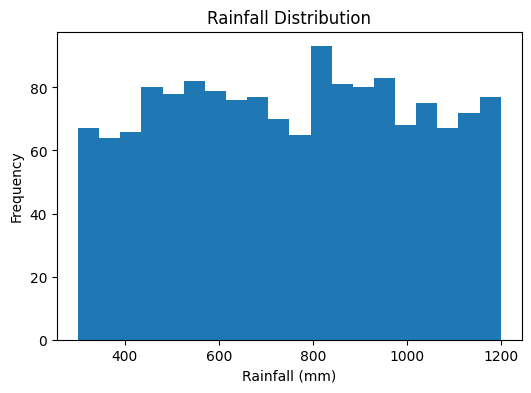

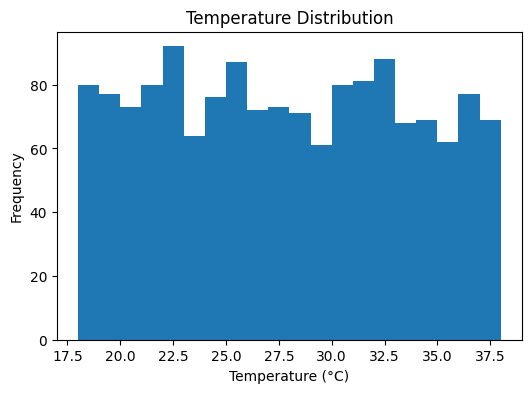

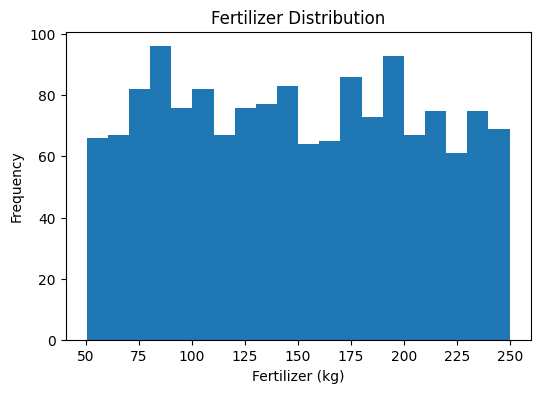

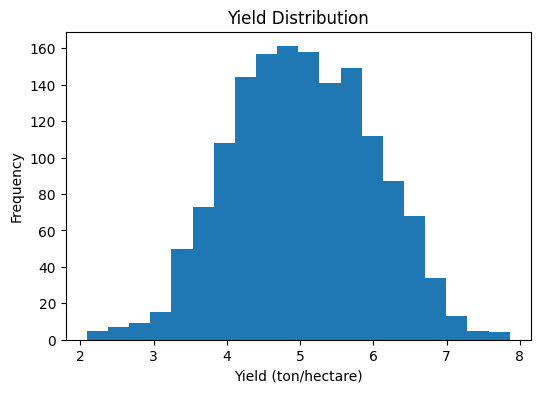

In [4]:
# Q4 Distribution Analysis

plt.figure(figsize=(6,4))
plt.hist(df['rainfall_mm'], bins=20)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df['temperature_c'], bins=20)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df['fertilizer_kg'], bins=20)
plt.title("Fertilizer Distribution")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield (ton/hectare)")
plt.ylabel("Frequency")
plt.show()


Crop Type Frequency:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


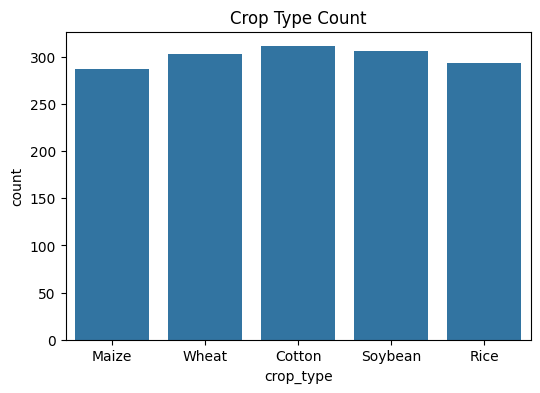


Most Frequent Crop:
Cotton


In [5]:
# Q5 Crop Type Analysis
crop_counts = df['crop_type'].value_counts()

print("\nCrop Type Frequency:")
print(crop_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='crop_type', data=df)
plt.title("Crop Type Count")
plt.show()

print("\nMost Frequent Crop:")
print(crop_counts.idxmax())



Soil Type Frequency:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


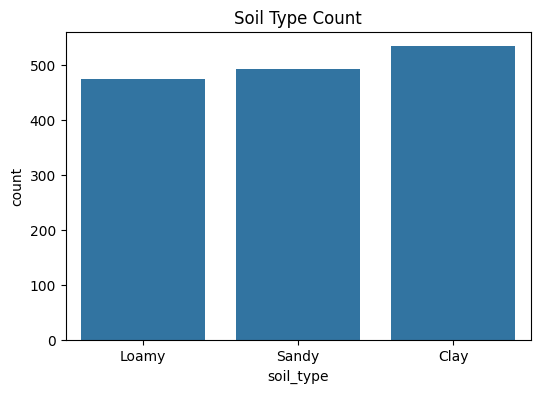


Most Common Soil Type:
Clay


In [6]:
# Q6 Soil Type Analysis

soil_counts = df['soil_type'].value_counts()

print("\nSoil Type Frequency:")
print(soil_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='soil_type', data=df)
plt.title("Soil Type Count")
plt.show()

print("\nMost Common Soil Type:")
print(soil_counts.idxmax())

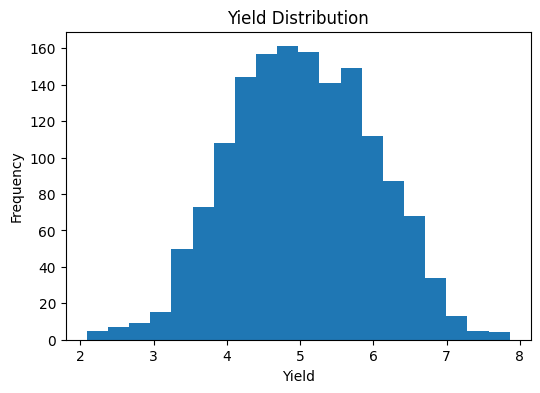

In [7]:
# Q7 Yield Distribution

plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

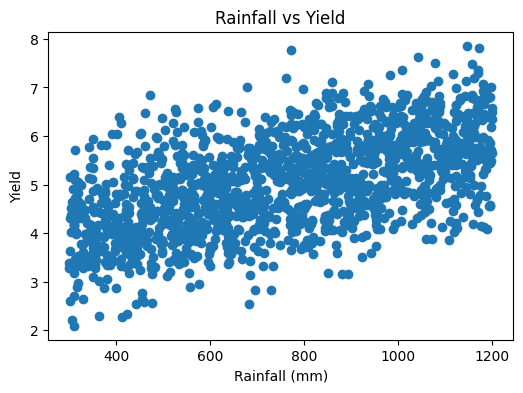

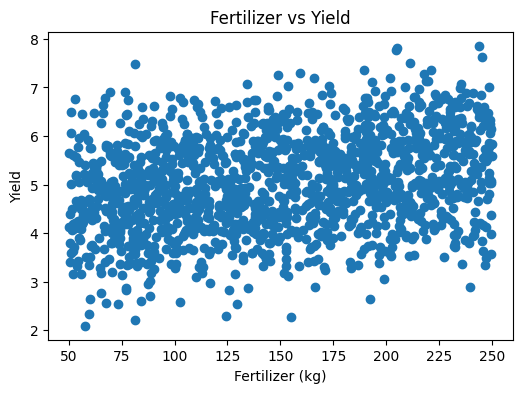

In [8]:
# Q8 Scatter Plot Analysis

plt.figure(figsize=(6,4))
plt.scatter(df['rainfall_mm'],
            df['yield_ton_per_hectare'])
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['fertilizer_kg'],
            df['yield_ton_per_hectare'])
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()


Correlation Matrix:
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412   

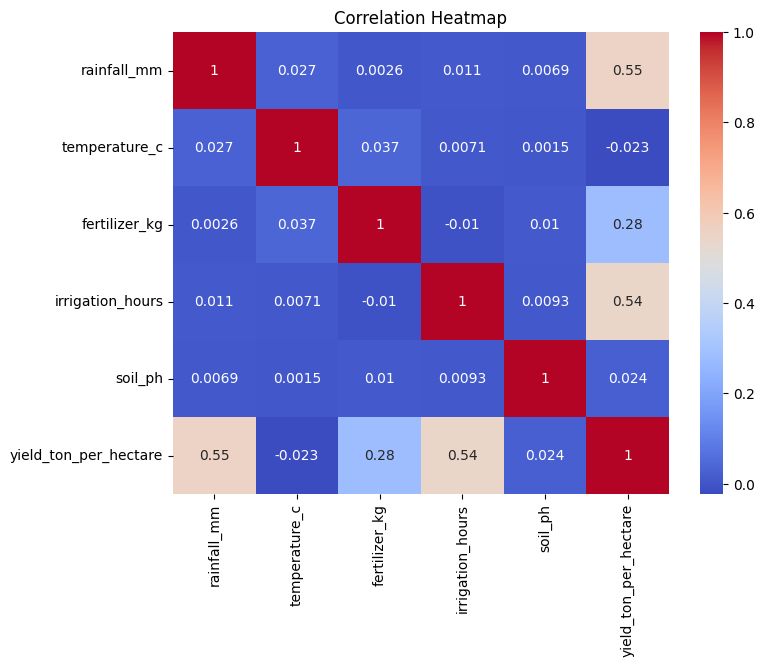


Correlation with Yield:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [9]:
# Q9 Correlation Analysis

numerical_df = df.select_dtypes(include=np.number)

corr_matrix = numerical_df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

yield_corr = corr_matrix['yield_ton_per_hectare']\
                .sort_values(ascending=False)

print("\nCorrelation with Yield:")
print(yield_corr)


In [10]:
# Q10 Group Based Analysis

crop_yield = df.groupby('crop_type')[
    'yield_ton_per_hectare'
].mean()

soil_yield = df.groupby('soil_type')[
    'yield_ton_per_hectare'
].mean()

print("\nAverage Yield by Crop:")
print(crop_yield)

print("\nAverage Yield by Soil:")
print(soil_yield)

print("\nHighest Yield Crop:")
print(crop_yield.idxmax())

print("\nHighest Yield Soil:")
print(soil_yield.idxmax())


Average Yield by Crop:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Highest Yield Crop:
Rice

Highest Yield Soil:
Loamy


In [11]:
# Q11 One Hot Encoding

categorical_cols = ['crop_type', 'soil_type']

print("\nCategorical Columns:")
print(categorical_cols)

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=False
)

print("\nEncoded Dataset First 5 Rows:")
print(df_encoded.head())


Categorical Columns:
['crop_type', 'soil_type']

Encoded Dataset First 5 Rows:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False   
4                   5.17              True            False           Fals

In [12]:
# Q12 Feature Selection

X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

y = df_encoded['yield_ton_per_hectare']

print("\nTarget Variable:")
print("yield_ton_per_hectare")


Target Variable:
yield_ton_per_hectare


In [13]:
# Q13 Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nX_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)


X_train Shape: (1200, 13)
X_test Shape: (300, 13)
y_train Shape: (1200,)
y_test Shape: (300,)


In [14]:
# Q14 Linear Regression

model = LinearRegression()

model.fit(X_train, y_train)

print("\nIntercept:")
print(model.intercept_)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nModel Coefficients:")
print(coefficients)

highest_positive = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print("\nFeature with Highest Positive Coefficient:")
print(highest_positive.iloc[0])


Intercept:
1.9111026182800726

Model Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5    crop_type_Cotton    -0.386623
6     crop_type_Maize    -0.147693
7      crop_type_Rice     0.477369
8   crop_type_Soybean     0.095096
9     crop_type_Wheat    -0.038149
10     soil_type_Clay     0.062653
11    soil_type_Loamy     0.365627
12    soil_type_Sandy    -0.428280

Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.477369
Name: 7, dtype: object
